In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('./data/bike_demand.csv')
df

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014,119
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014,89
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014,90
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981,61


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  str    
 1   year        17379 non-null  int64  
 2   month       17379 non-null  int64  
 3   hour        17379 non-null  int64  
 4   holiday     17379 non-null  bool   
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  bool   
 7   weather     17379 non-null  str    
 8   temp        17379 non-null  float64
 9   feel_temp   17379 non-null  float64
 10  humidity    17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  count       17379 non-null  int64  
dtypes: bool(2), float64(4), int64(5), str(2)
memory usage: 1.5 MB


In [6]:
df.describe()

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,6.537775,11.546752,3.003683,20.376474,23.788755,0.627229,12.736540,189.463088
std,0.500008,3.438776,6.914405,2.005771,7.894801,8.592511,0.192930,8.196795,181.387599
min,0.000000,1.000000,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.000000,6.000000,1.000000,13.940000,16.665000,0.480000,7.001500,40.000000
50%,1.000000,7.000000,12.000000,3.000000,20.500000,24.240000,0.630000,12.998000,142.000000
75%,1.000000,10.000000,18.000000,5.000000,27.060000,31.060000,0.780000,16.997900,281.000000
max,1.000000,12.000000,23.000000,6.000000,41.000000,50.000000,1.000000,56.996900,977.000000


In [7]:
df.isna().sum()

season        0
year          0
month         0
hour          0
holiday       0
weekday       0
workingday    0
weather       0
temp          0
feel_temp     0
humidity      0
windspeed     0
count         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

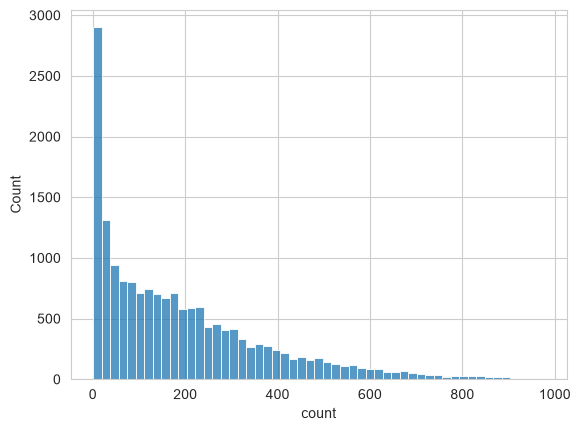

In [10]:
sns.histplot(df['count'])
plt.show()

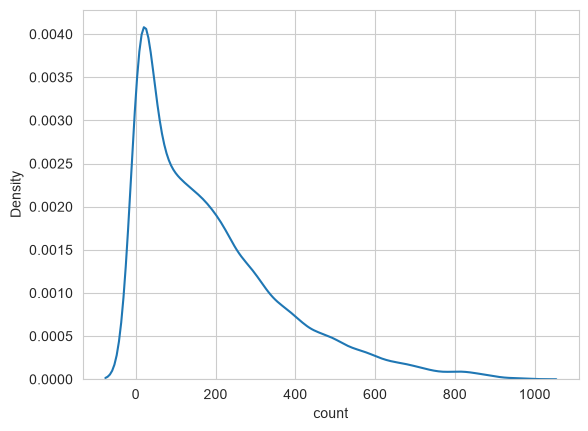

In [11]:
sns.kdeplot(df['count'])
plt.show()

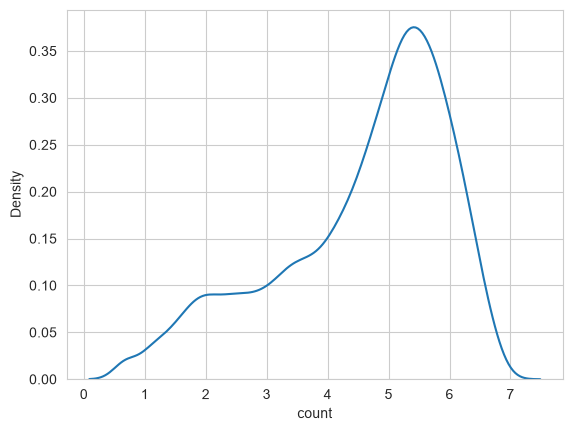

In [12]:
sns.kdeplot(np.log1p(df['count']))
plt.show()

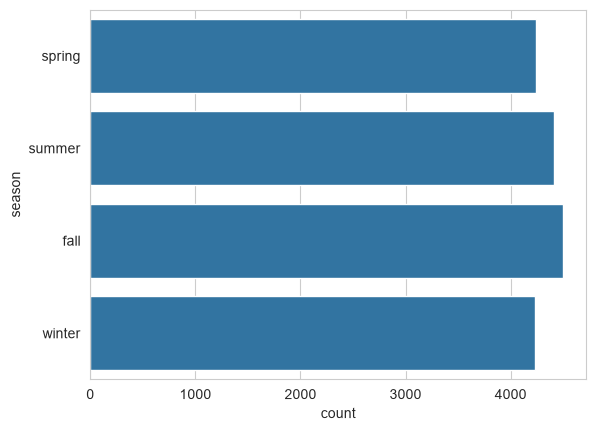

In [13]:
sns.countplot(df['season'])
plt.show()

In [14]:
num_cols = list(df.select_dtypes(include='number').columns)
num_cols.remove('count')
num_cols

['year',
 'month',
 'hour',
 'weekday',
 'temp',
 'feel_temp',
 'humidity',
 'windspeed']

In [15]:
bool_cols = list(df.select_dtypes(include='bool').columns)
bool_cols

['holiday', 'workingday']

In [16]:
str_cols = list(df.select_dtypes(include = 'str').columns)
str_cols

['season', 'weather']

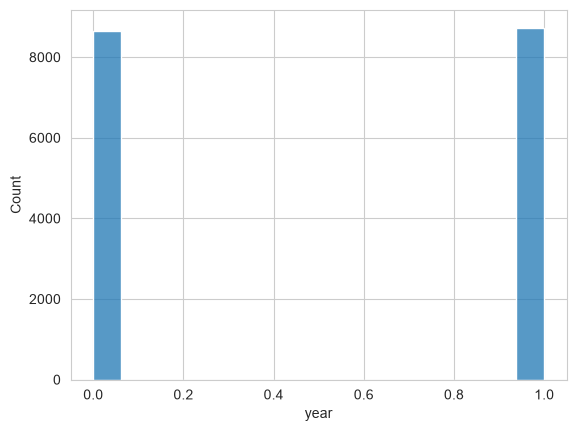

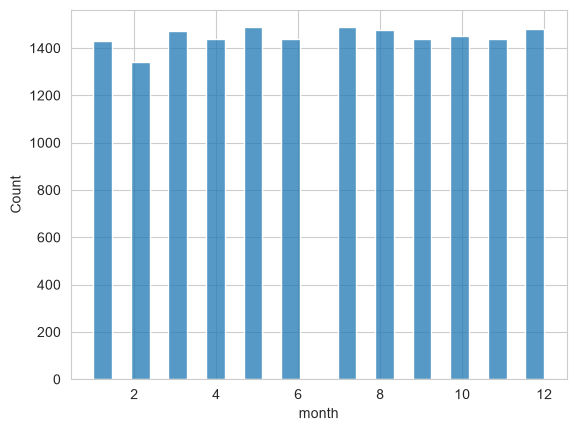

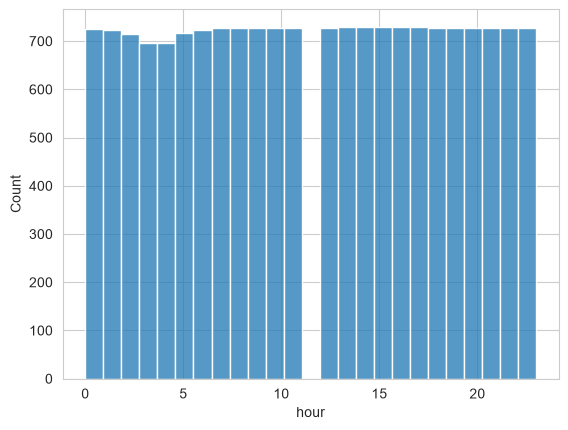

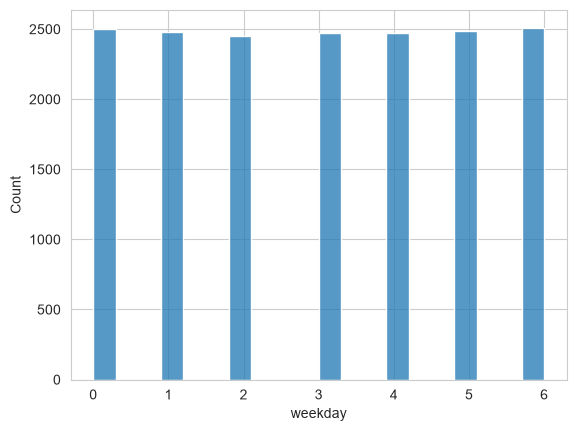

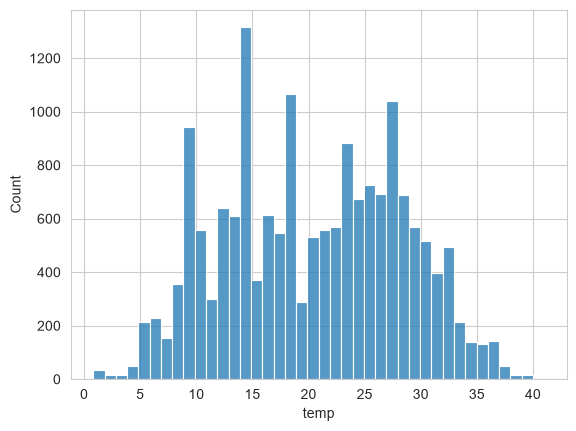

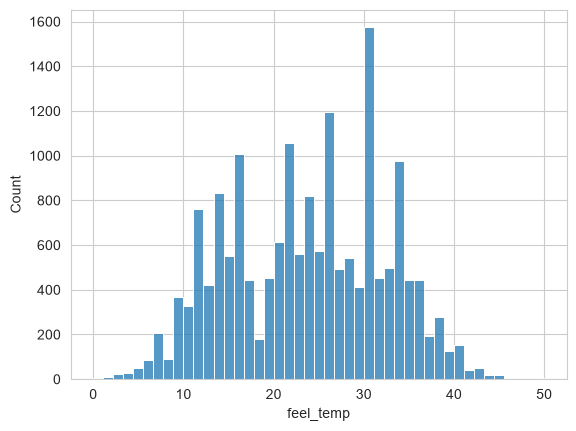

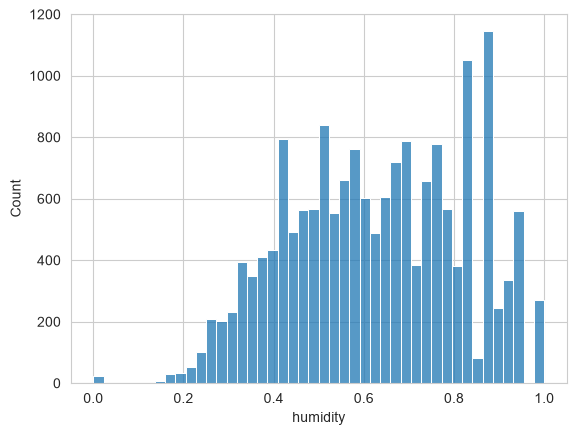

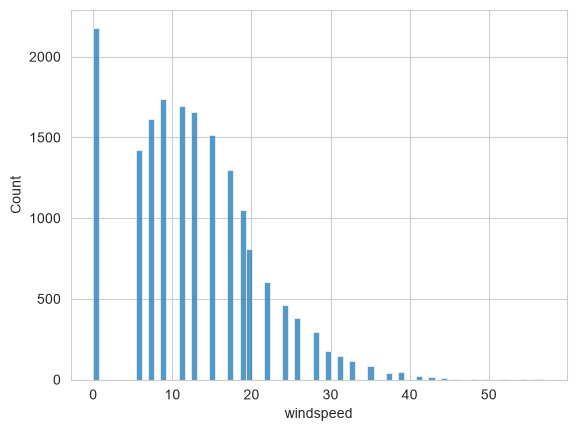

In [17]:
for col in num_cols:
    sns.histplot(df[col])
    plt.show()

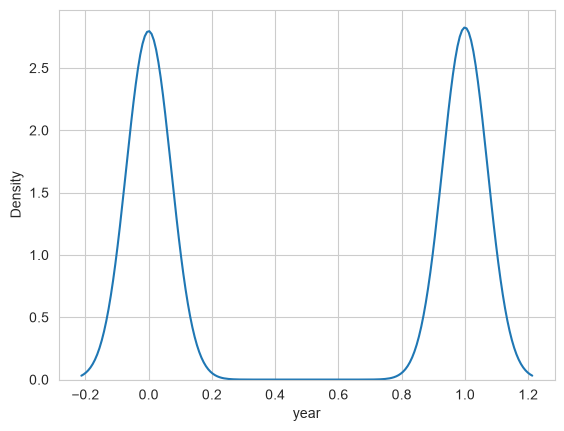

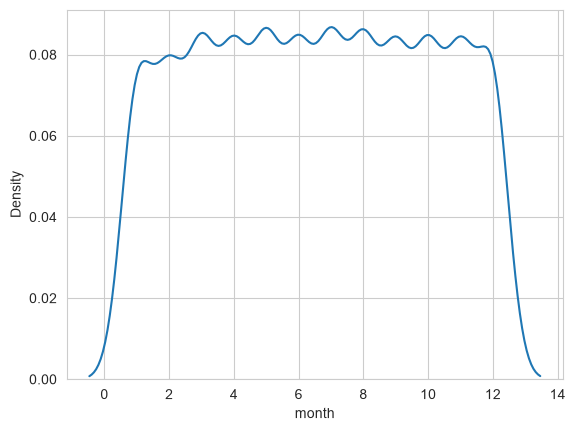

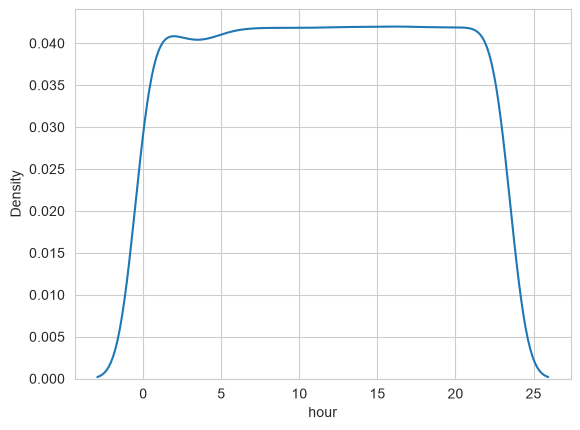

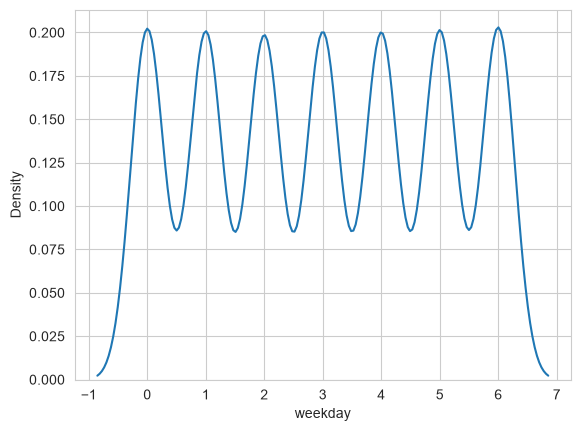

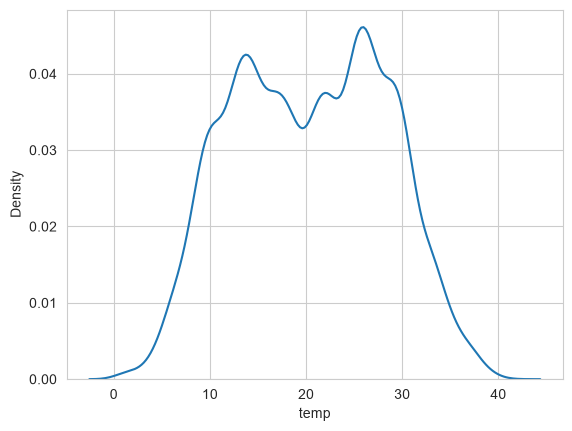

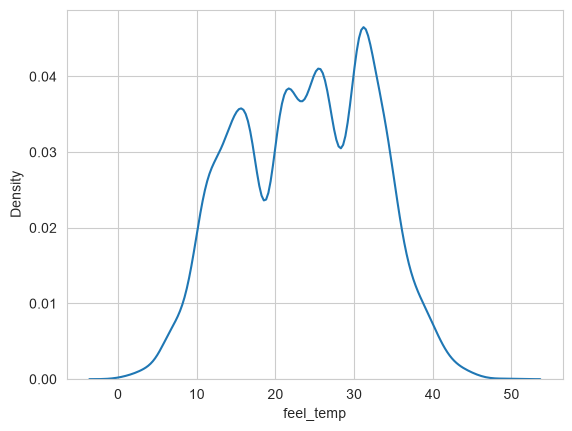

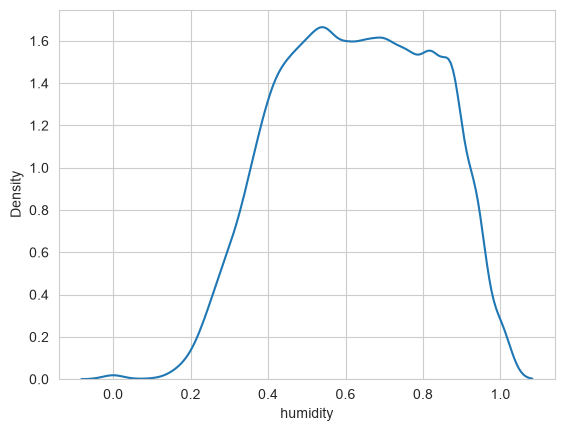

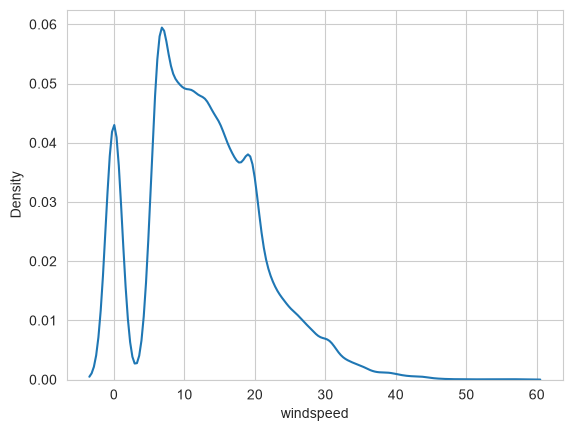

In [18]:
for col in num_cols:
    sns.kdeplot(df[col])
    plt.show()

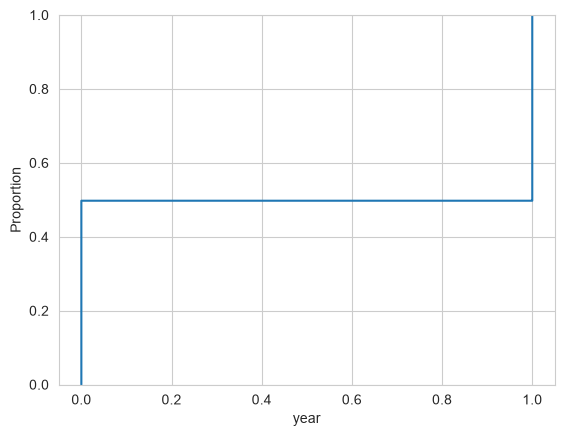

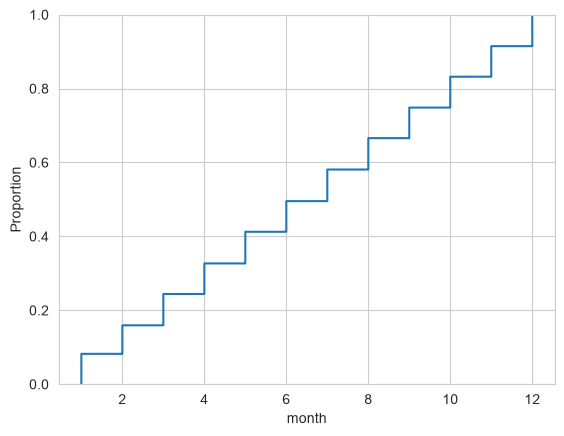

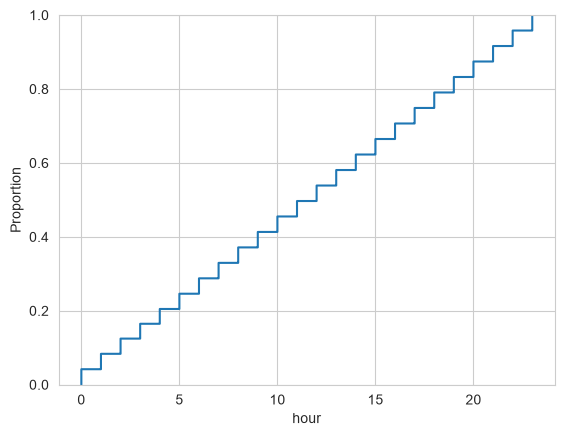

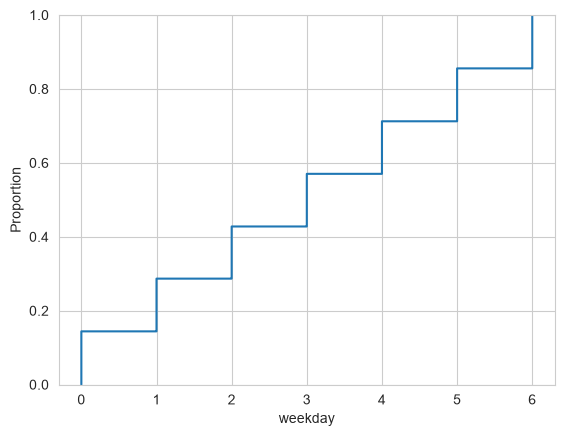

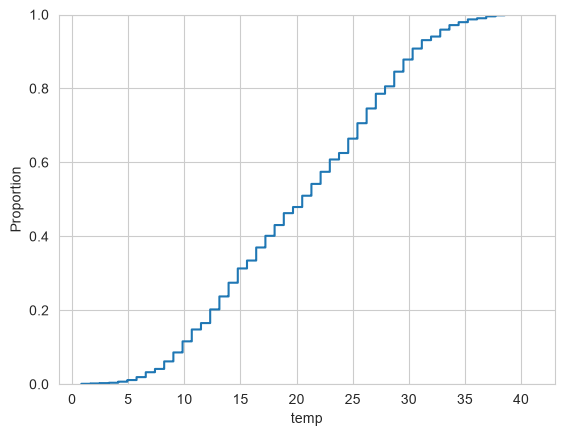

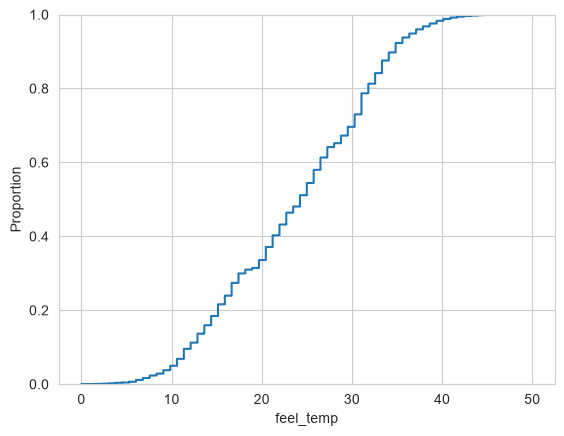

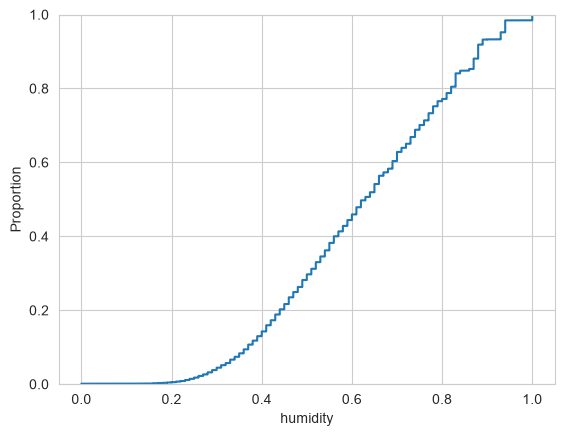

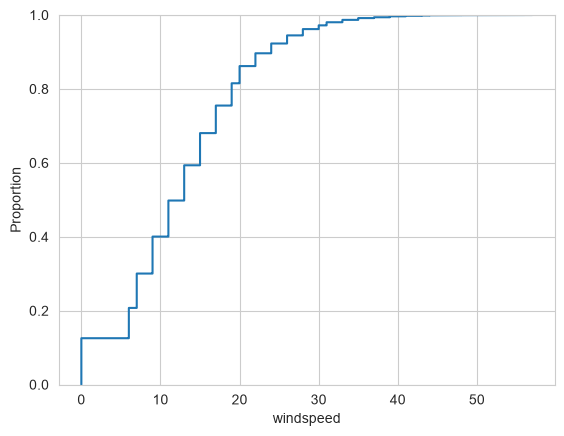

In [19]:
for col in num_cols:
    sns.ecdfplot(df[col])
    plt.show()

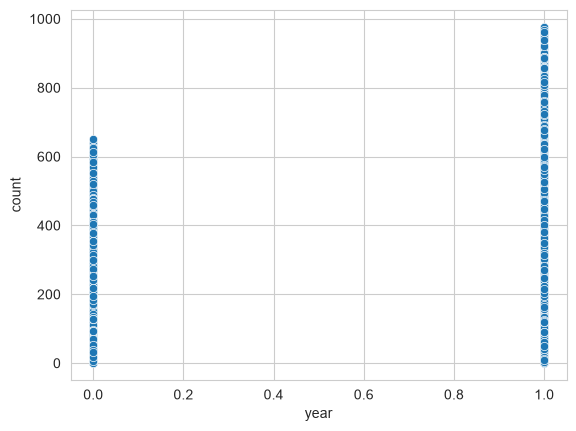

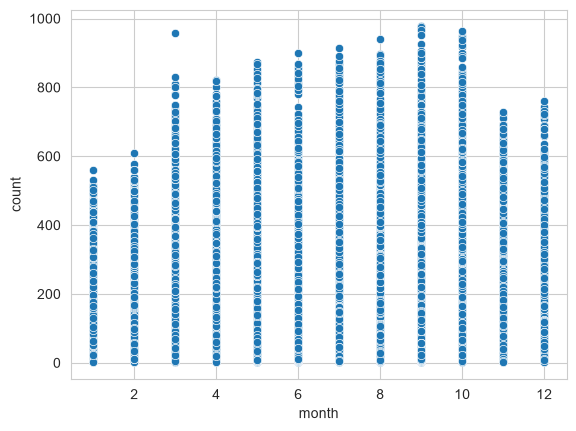

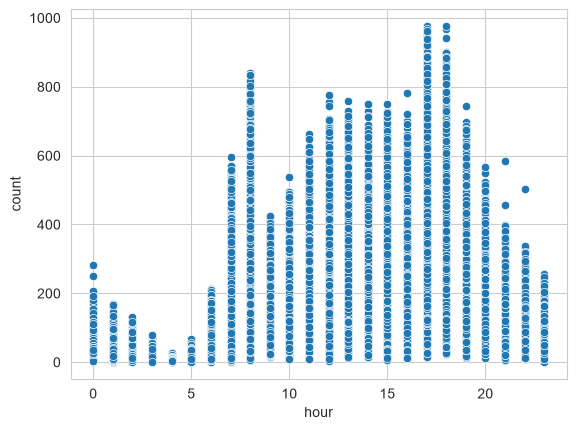

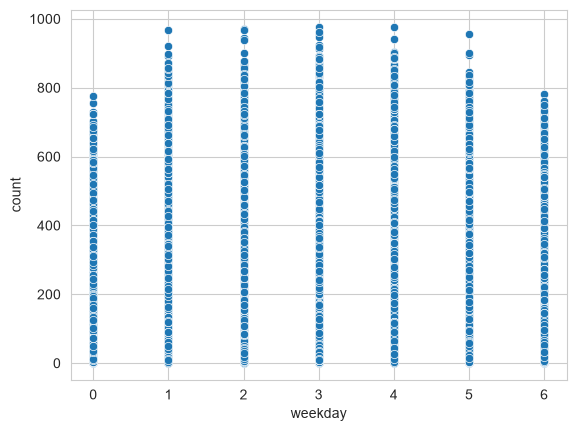

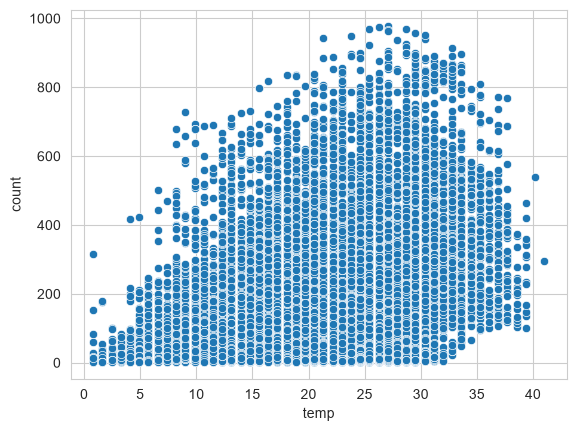

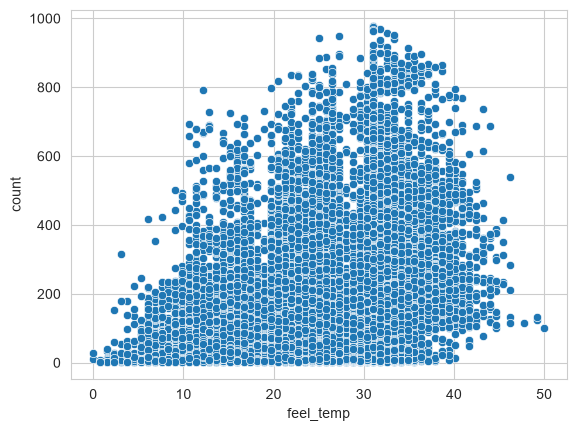

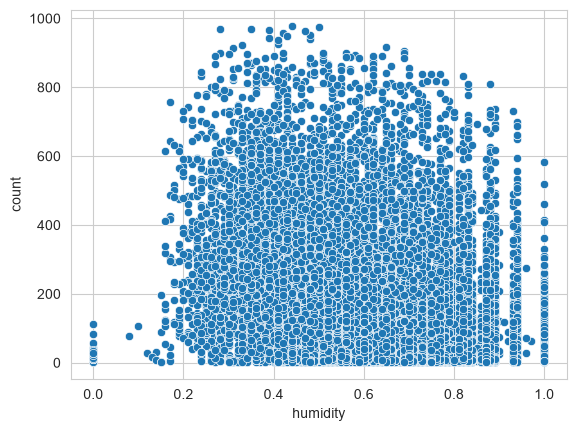

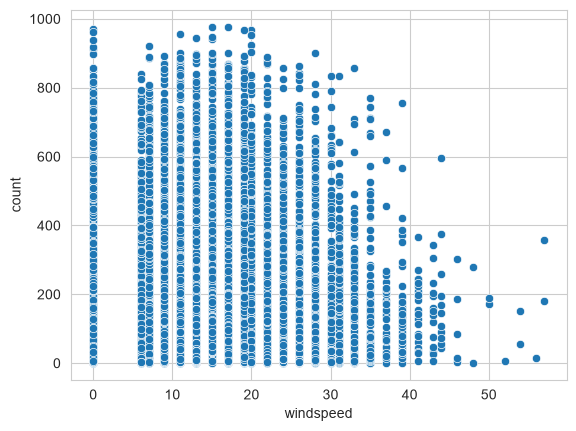

In [20]:
for col in num_cols:
    sns.scatterplot(x = col, y = 'count', data = df)
    plt.show()

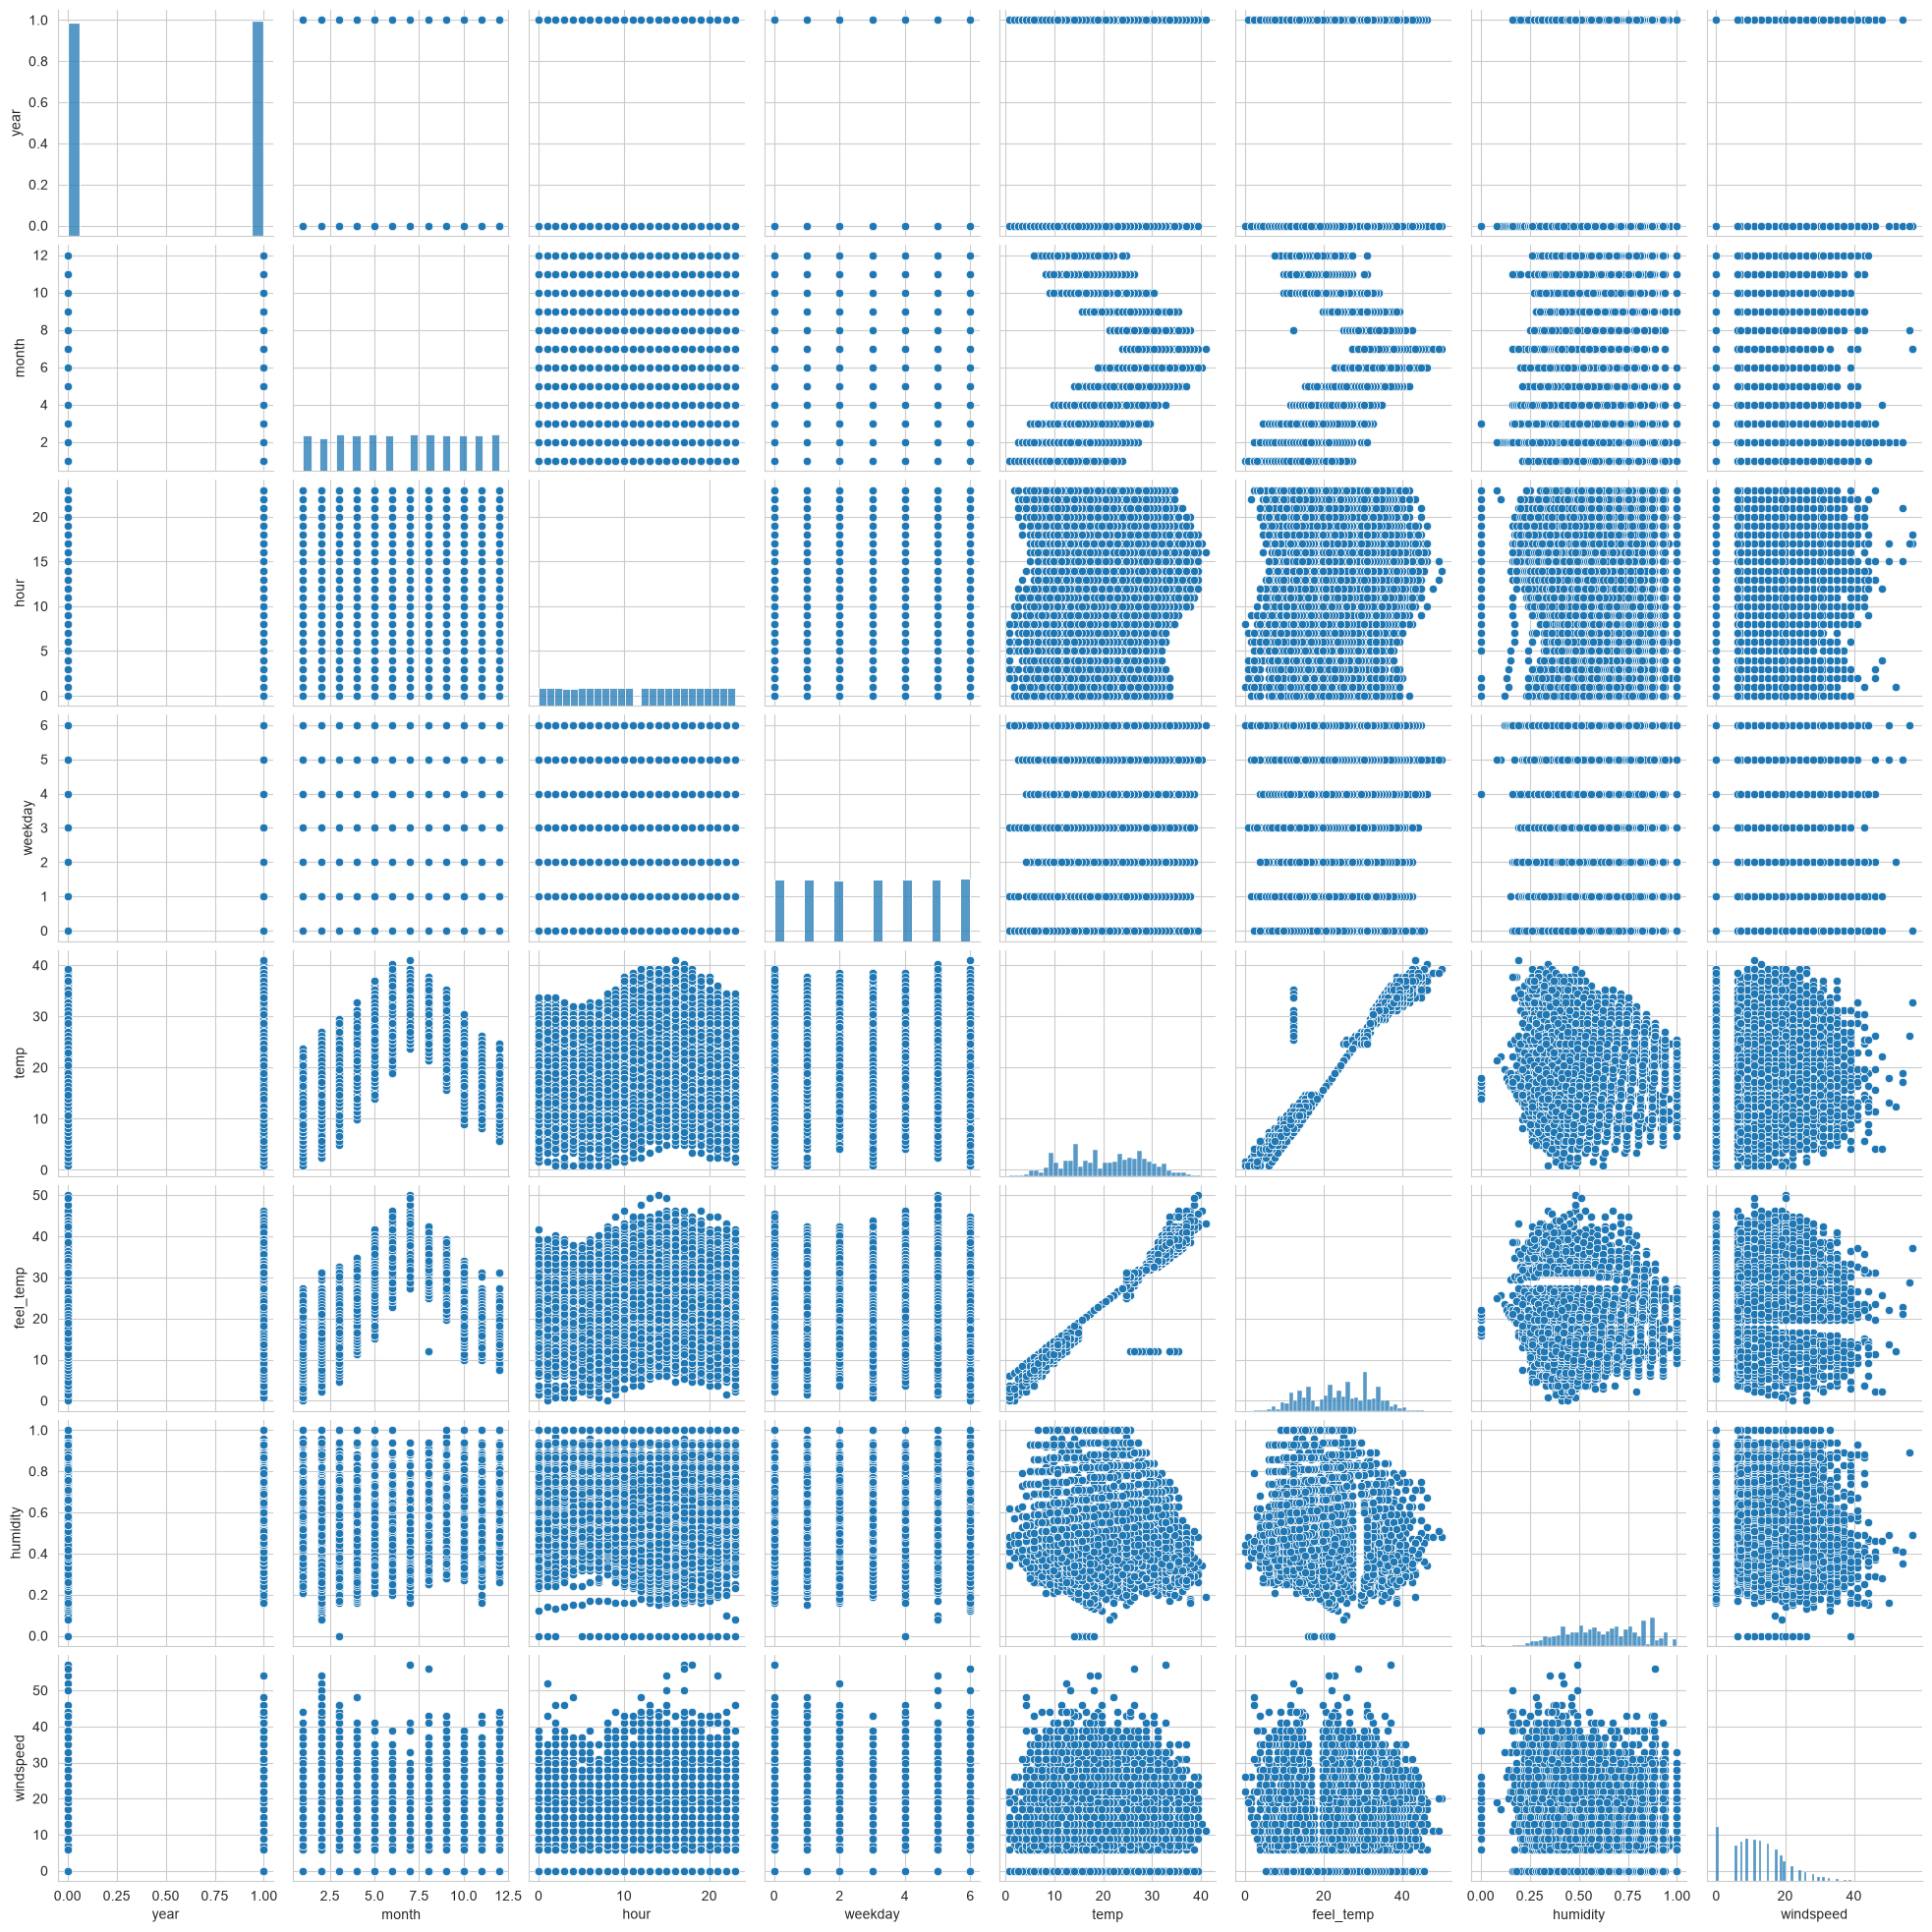

In [21]:
sns.pairplot(df[num_cols])
plt.show()

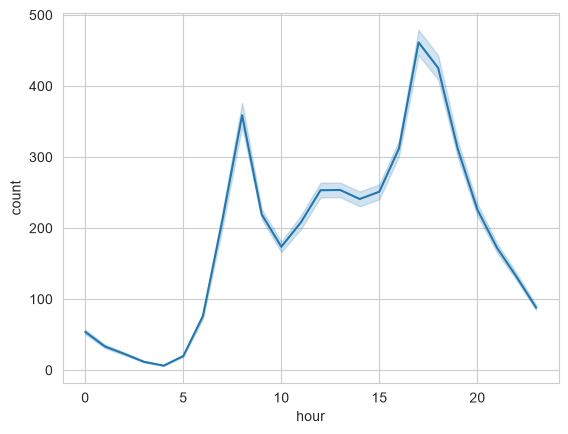

In [22]:
sns.lineplot(x = 'hour', y = 'count', data=df)
plt.show()

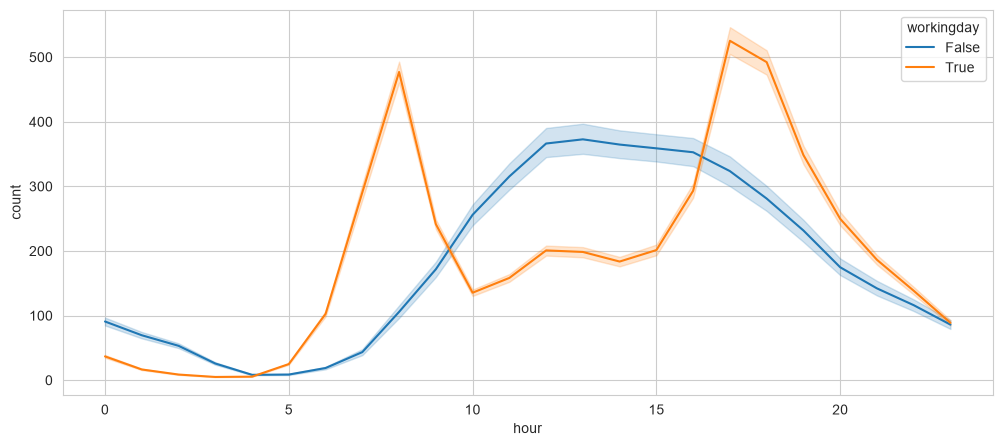

In [23]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='hour', y='count', hue='workingday', data=df)
plt.show()


In [24]:
df.loc[(df['feel_temp'] < 15) & (df['temp'] > 20), 'feel_temp'] = df['temp'] * 1.1
df['temp_diff'] = df['feel_temp'] - df['temp']
df['ideal_temp'] = ((df['temp'] >= 18) & (df['temp'] <= 28)).astype(int)

In [25]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [26]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

df['is_morning_rush'] = ((df['workingday'] == True) & (df['hour'].isin([7, 8, 9]))).astype(int)
df['is_evening_rush'] = ((df['workingday'] == True) & (df['hour'].isin([17, 18, 19]))).astype(int)
df['is_weekend_afternoon'] = ((df['workingday'] == False) & (df['hour'].between(12, 16))).astype(int)

In [27]:
X = df.drop(columns=['count', 'hour', 'month', 'weekday'])
y_log = np.log1p(df['count'])

In [28]:
X[bool_cols] = (X[bool_cols]).astype(int)
X[bool_cols]

,holiday,workingday
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
17374,0,1
17375,0,1
17376,0,1
17377,0,1


In [34]:
for col in str_cols:
    print(f"{col} : {X[col].unique()}")

season : <StringArray>
['spring', 'summer', 'fall', 'winter']
Length: 4, dtype: str
weather : <StringArray>
['clear', 'misty', 'rain', 'heavy_rain']
Length: 4, dtype: str


In [39]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

ohe = ColumnTransformer([
    ('weather', OrdinalEncoder(categories=[['clear', 'misty', 'rain', 'heavy_rain']]), ['weather']),
    ('season', OrdinalEncoder(categories=[['spring', 'summer', 'fall', 'winter']]), ['season'])
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error

X_train, X_test, y_train, y_test = train_test_split(X,y_log,test_size=0.2, random_state=42)

In [40]:
X_train = ohe.fit_transform(X_train)
X_test = ohe.transform(X_test)

In [41]:
X_train

,weather,season,year,holiday,workingday,temp,feel_temp,humidity,windspeed,temp_diff,ideal_temp,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos,is_morning_rush,is_evening_rush,is_weekend_afternoon
335,0.0,0.0,0,0,0,8.20,9.850,0.55,15.0013,1.650,0,2.588190e-01,-9.659258e-01,5.000000e-01,0.866025,-0.781831,0.623490,0,0,0
7034,0.0,3.0,0,0,1,22.96,26.515,0.37,7.0015,3.555,1,-9.659258e-01,-2.588190e-01,-8.660254e-01,0.500000,0.974928,-0.222521,0,1,0
17155,0.0,0.0,1,0,0,13.12,14.395,0.36,31.0009,1.275,0,-5.000000e-01,-8.660254e-01,-2.449294e-16,1.000000,-0.781831,0.623490,0,0,1
2133,1.0,1.0,0,0,0,18.86,22.725,0.31,0.0000,3.865,1,-1.000000e+00,-1.836970e-16,8.660254e-01,-0.500000,0.000000,1.000000,0,0,0
8485,0.0,0.0,0,0,0,8.20,11.365,0.75,7.0015,3.165,0,1.000000e+00,6.123234e-17,-2.449294e-16,1.000000,0.000000,1.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11285,0.0,1.0,1,0,1,20.50,24.240,0.77,12.9980,3.740,1,5.000000e-01,-8.660254e-01,8.660254e-01,-0.500000,-0.974928,-0.222521,0,0,0
11965,0.0,1.0,1,0,1,26.24,31.060,0.38,15.0013,4.820,1,-1.000000e+00,-1.836970e-16,5.000000e-01,-0.866025,-0.974928,-0.222521,0,1,0
5390,0.0,2.0,0,0,1,32.80,36.365,0.43,19.0012,3.565,0,1.224647e-16,-1.000000e+00,-8.660254e-01,-0.500000,0.433884,-0.900969,0,0,0
860,0.0,0.0,0,0,1,9.84,9.850,0.65,27.9993,0.010,0,9.659258e-01,-2.588190e-01,8.660254e-01,0.500000,0.974928,-0.222521,1,0,0


## Linear Regression

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

In [44]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['weather','season','year',...,'is_morning_rush','is_evening_rush', 'is_weekend_afternoon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [45]:
root_mean_squared_log_error(y_test, pipe.predict(X_test))

0.16632473471435108

In [46]:
pipe.score(X_test, y_test)

0.7624837049918923

In [49]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    "Ridge Regression": Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=18, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost (GPU)": XGBRegressor(device='cuda', tree_method='hist', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test, y_pred_log)
    
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
    
    results.append({
        'Model': name,
        'RMSLE (Lower=Better)': rmsle,
        'R2 Score (Higher=Better)': r2,
        'MAE in Bikes (Original Scale)': mae_orig
    })
    print(f"{name:<22} | RMSLE: {rmsle:.4f} | R2: {r2:.4f} | MAE: {mae_orig:.1f} bikes")

df_results = pd.DataFrame(results).sort_values(by='RMSLE (Lower=Better)').reset_index(drop=True)
print("\n" + "="*70)
print("DAY 5 URBAN BIKE DEMAND REGRESSION LEADERBOARD")
print("="*70)
print(df_results.to_string(index=False))


Linear Regression      | RMSLE: 0.6837 | R2: 0.7625 | MAE: 68.7 bikes
Ridge Regression       | RMSLE: 0.6837 | R2: 0.7625 | MAE: 68.7 bikes
Decision Tree          | RMSLE: 0.4056 | R2: 0.9164 | MAE: 34.9 bikes
Random Forest          | RMSLE: 0.3158 | R2: 0.9493 | MAE: 24.5 bikes
HistGradientBoosting   | RMSLE: 0.2978 | R2: 0.9549 | MAE: 25.3 bikes
LightGBM               | RMSLE: 0.2950 | R2: 0.9558 | MAE: 25.5 bikes
CatBoost               | RMSLE: 0.2769 | R2: 0.9610 | MAE: 22.4 bikes
XGBoost (GPU)          | RMSLE: 0.2939 | R2: 0.9561 | MAE: 24.6 bikes

DAY 5 URBAN BIKE DEMAND REGRESSION LEADERBOARD
               Model  RMSLE (Lower=Better)  R2 Score (Higher=Better)  MAE in Bikes (Original Scale)
            CatBoost              0.276905                  0.961041                      22.379936
       XGBoost (GPU)              0.293943                  0.956099                      24.636776
            LightGBM              0.295010                  0.955780                      25

In [50]:
from sklearn.neural_network import MLPRegressor

pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True, random_state=42))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['weather','season','year',...,'is_morning_rush','is_evening_rush', 'is_weekend_afternoon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [51]:
root_mean_squared_log_error(y_test, pipe.predict(X_test))

0.08277831392745999

In [52]:
r2_score(y_test, pipe.predict(X_test))

0.9485037977399673

In [54]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [6, 7, 8, 9, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 3.0, 5.0, 10.0]
}

xgb_model = XGBRegressor(device='cuda', tree_method='hist', random_state=42)

print("Tuning GPU XGBoost via RandomizedSearchCV (30 iterations)...")
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1
)
search.fit(X_train, y_train)

best_xgb = search.best_estimator_

y_pred_log = best_xgb.predict(X_test)
tuned_rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))
tuned_r2 = r2_score(y_test, y_pred_log)

y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
tuned_mae = mean_absolute_error(y_test_orig, y_pred_orig)

print("\n" + "="*50)
print(f"TUNED GPU XGBOOST TEST RMSLE: {tuned_rmsle:.4f}")
print(f"TUNED GPU XGBOOST TEST R2:    {tuned_r2:.4f} ({tuned_r2*100:.2f}%)")
print(f"TUNED GPU XGBOOST TEST MAE:   {tuned_mae:.2f} bikes/hour")
print("="*50)
print("\nBest Parameters:", search.best_params_)

df_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (%)': best_xgb.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

print("\nTOP 10 MOST INFLUENTIAL DEMAND DRIVERS:")
print(df_imp.head(10).to_string(index=False))


Tuning GPU XGBoost via RandomizedSearchCV (30 iterations)...

TUNED GPU XGBOOST TEST RMSLE: 0.2783
TUNED GPU XGBOOST TEST R2:    0.9607 (96.07%)
TUNED GPU XGBOOST TEST MAE:   22.37 bikes/hour

Best Parameters: {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

TOP 10 MOST INFLUENTIAL DEMAND DRIVERS:
             Feature  Importance (%)
            hour_cos       23.501242
            hour_sin       20.810619
          workingday       10.900016
     is_evening_rush        8.744007
     is_morning_rush        8.392654
                year        5.774408
              season        4.420331
is_weekend_afternoon        4.332861
           feel_temp        2.830096
                temp        2.740038
